## Background
This Jupiter Notebook aims to set the upgraded baseline for manipulation classification task. \
At first, different features are engineered from text. Then 2 models will be tested: CatBoost and LightGBM.

## Imports

In [2]:
import os
import warnings
import pandas as pd
import numpy as np
from collections import Counter
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
from langdetect import detect
import emoji
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt

In [3]:
warnings.filterwarnings("ignore")

## Constants

In [ ]:
TRAIN_PATH = "../../data/"
TRAIN_NAME = "train.parquet"

In [ ]:
TEST_PATH = "../../data/"
TEST_NAME = "test_lang.csv"

## Read data

In [6]:
train = pd.read_parquet(os.path.join(TRAIN_PATH, TRAIN_NAME))
train.head()

,id,content,lang,manipulative,techniques,trigger_words
0,0bb0c7fa-101b-4583-a5f9-9d503339141c,Новий огляд мапи DeepState від російського вій...,uk,True,"[euphoria, loaded_language]","[[27, 63], [65, 88], [90, 183], [186, 308]]"
1,7159f802-6f99-4e9d-97bd-6f565a4a0fae,Недавно 95 квартал жёстко поглумился над русск...,ru,True,"[loaded_language, cherry_picking]","[[0, 40], [123, 137], [180, 251], [253, 274]]"
2,e6a427f1-211f-405f-bd8b-70798458d656,🤩\nТим часом йде евакуація Бєлгородського авто...,uk,True,"[loaded_language, euphoria]","[[55, 100]]"
3,1647a352-4cd3-40f6-bfa1-d87d42e34eea,В Україні найближчим часом мають намір посилит...,uk,False,None,None
4,9c01de00-841f-4b50-9407-104e9ffb03bf,"Расчёты 122-мм САУ 2С1 ""Гвоздика"" 132-й бригад...",ru,True,[loaded_language],"[[114, 144]]"


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3822 entries, 0 to 3821
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             3822 non-null   object
 1   content        3822 non-null   object
 2   lang           3822 non-null   object
 3   manipulative   3822 non-null   bool  
 4   techniques     2589 non-null   object
 5   trigger_words  2589 non-null   object
dtypes: bool(1), object(5)
memory usage: 153.2+ KB


In [8]:
# If there are no manipulations in the text, we will set techniques and trigger_words to empty lists
train['techniques'] = train['techniques'].apply(lambda x: [] if x is None else x)
train['trigger_words'] = train['trigger_words'].apply(lambda x: [] if x is None else x)

In [9]:
# Extract trigger_words phrases from the text:
trigger_words_phrases = []
for text, trigger_words in zip(train.content.values, train.trigger_words.values):
    if text is None or trigger_words is None:
        trigger_words_phrases.append([])
        continue
    trigger_words_phrases.append([text[i:j] for i, j in trigger_words])
train["trigger_words_phrases"] = trigger_words_phrases

In [10]:
# Number of occurrences of each technique
technique_counts = Counter([tech for sublist in train['techniques'] for tech in sublist])
technique_counts

Counter({'euphoria': 462,
         'loaded_language': 1973,
         'cherry_picking': 512,
         'glittering_generalities': 483,
         'cliche': 463,
         'appeal_to_fear': 300,
         'bandwagon': 157,
         'fud': 385,
         'whataboutism': 158,
         'straw_man': 138})

In [11]:
unique_techniques = Counter()
for t in train["techniques"]:
    unique_techniques.update(t)

techniques_dict = {k: i for i, k in enumerate(unique_techniques.keys())}
techniques_dict

{'euphoria': 0,
 'loaded_language': 1,
 'cherry_picking': 2,
 'glittering_generalities': 3,
 'cliche': 4,
 'appeal_to_fear': 5,
 'bandwagon': 6,
 'fud': 7,
 'whataboutism': 8,
 'straw_man': 9}

In [12]:
test = pd.read_csv(os.path.join(TEST_PATH, TEST_NAME))
test.head()

,id,content,trigger_words,techniques,lang
0,521cd2e8-dd9f-42c4-98ba-c0c8890ff1ba,"Они просрали нашу технику, положили кучу людей...","[(0, 12), (27, 46), (48, 71), (131, 162), (164...","['fud', 'loaded_language']",ru
1,9b2a61e4-d14e-4ff7-b304-e73d720319bf,❗️\nКитай предлагает отдать оккупированные тер...,"[(374, 425)]",['loaded_language'],ru
2,f0f1c236-80a8-4d25-b30c-a420a39be632,Сегодня будет ровно 6 месяцев с этого обещания...,"[(0, 127)]",['loaded_language'],ru
3,31ea05ba-2c2b-4b84-aba7-f3cf6841b204,⚡️\nІзраїль вперше у світі збив балістичну рак...,[],[],uk
4,a79e13ec-6d9a-40b5-b54c-7f4f743a7525,Склав невелику навчально-методичну таблицю на ...,"[(87, 103), (127, 136), (170, 189), (204, 255)...",['loaded_language'],uk


In [13]:
import ast

test['trigger_words'] = test['trigger_words'].apply(lambda x: x if isinstance(x, str) else "[]")

test['trigger_words'] = test['trigger_words'].apply(ast.literal_eval)
test['techniques'] = test['techniques'].apply(ast.literal_eval)

## Feature engineering

### Get sentence embeddings

In [ ]:
model = SentenceTransformer('Alibaba-NLP/gte-multilingual-base', trust_remote_code=True, device="cuda")

In [ ]:
all_texts_to_encode = train["content"].to_list() + train["trigger_words_phrases"].apply(lambda x: ", ".join(x)).to_list() + test["content"].to_list()
all_texts_to_encode = [t[:5000] for t in all_texts_to_encode]

text_vectors_all = model.encode(all_texts_to_encode, show_progress_bar=True, normalize_embeddings=True, batch_size=8)
text_vectors = text_vectors_all[:len(train)]
triger_phrases_vectors = text_vectors_all[len(train):-len(test)]
text_vectors_test = text_vectors_all[-len(test):]

### Construct clusters of trigger phrases

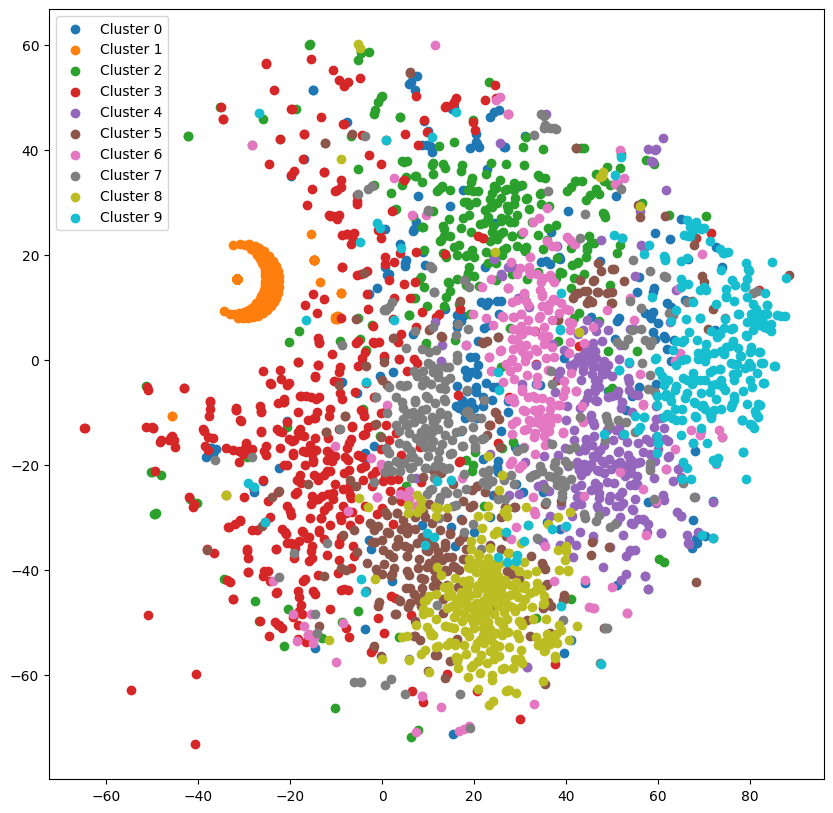

In [16]:
# Cluster and visualize the triger_phrases_vectors:
kmeans = KMeans(n_clusters=10, random_state=0).fit(triger_phrases_vectors)
clusters = kmeans.predict(triger_phrases_vectors)

tsne = TSNE(n_components=2, random_state=0)
tsne_res = tsne.fit_transform(triger_phrases_vectors)

plt.figure(figsize=(10, 10))
for i in range(10):
    plt.scatter(tsne_res[clusters == i, 0], tsne_res[clusters == i, 1], label=f"Cluster {i}")
plt.legend()
plt.show()

# Get vectors for cluster centers:
cluster_centers = kmeans.cluster_centers_

### Get similar samples

In [17]:
# For each sample id get 20 most similar texts and their techniques:

N = 20

sim_texts, sim_measur, sim_techniques = [], [], []
for i in tqdm(range(len(train))):
    sample_vector = text_vectors[i]
    similarities = cosine_similarity(sample_vector.reshape(1, -1), triger_phrases_vectors)[0]
    # Make sure that the sample is not in the top:
    similarities[i] = 0
    most_similar_indices = similarities.argsort()[-N:][::-1]
    sim_texts.append([train["content"].iloc[j] for j in most_similar_indices])
    sim_measur.append([similarities[j] for j in most_similar_indices])
    sim_techniques.append([train["techniques"].iloc[j] for j in most_similar_indices])

# The same but text_vectors instead of triger_phrases_vectors:
sim_texts_t, sim_measur_t, sim_techniques_t = [], [], []
for i in tqdm(range(len(train))):
    sample_vector = text_vectors[i]
    similarities = cosine_similarity(sample_vector.reshape(1, -1), text_vectors)[0]
    # Make sure that the sample is not in the top:
    similarities[i] = 0
    most_similar_indices = similarities.argsort()[-N:][::-1]
    sim_texts_t.append([train["content"].iloc[j] for j in most_similar_indices])
    sim_measur_t.append([similarities[j] for j in most_similar_indices])
    sim_techniques_t.append([train["techniques"].iloc[j] for j in most_similar_indices])

100%|██████████| 3822/3822 [00:39<00:00, 97.86it/s] 


In [18]:
# for each sample make the tecniques counter:
sim_techniques_counters = []
for i in range(len(sim_techniques)):
    c = Counter()
    for t in sim_techniques[i]:
        c.update(t)
    sim_techniques_counters.append(c)

sim_techniques_counters_t = []
for i in range(len(sim_techniques_t)):
    c = Counter()
    for t in sim_techniques_t[i]:
        c.update(t)
    sim_techniques_counters_t.append(c)

# Make the vector for each sample:
sim_techniques_vectors = []
for i in range(len(sim_techniques_counters)):
    v = np.zeros(len(techniques_dict) * 2)
    for j, t in enumerate(unique_techniques):
        v[j] = sim_techniques_counters[i][t]
    for j, t in enumerate(unique_techniques):
        v[j + len(techniques_dict)] = sim_techniques_counters_t[i][t]
    sim_techniques_vectors.append(v)

# get the distance from the cluster centers (cosine similarity):
distances = []
for i in range(len(sim_techniques_vectors)):
    distances.append(cosine_similarity(text_vectors[i].reshape(1, -1), cluster_centers)[0])

# Concat the vectors and sim_techniques_vectors:
sim_techniques_vectors = np.array(sim_techniques_vectors)
sim_techniques_vectors = np.concatenate([sim_techniques_vectors, distances], axis=1)

In [19]:
sim_texts_test, sim_measur_test, sim_techniques_test = [], [], []
for i in tqdm(range(len(test))):
    sample_vector = text_vectors_test[i]
    similarities = cosine_similarity(sample_vector.reshape(1, -1), triger_phrases_vectors)[0]
    most_similar_indices = similarities.argsort()[-N:][::-1]
    sim_texts_test.append([train["content"].iloc[j] for j in most_similar_indices])
    sim_measur_test.append([similarities[j] for j in most_similar_indices])
    sim_techniques_test.append([train["techniques"].iloc[j] for j in most_similar_indices])

sim_texts_t_test, sim_measur_t_test, sim_techniques_t_test = [], [], []
for i in tqdm(range(len(test))):
    sample_vector = text_vectors_test[i]
    similarities = cosine_similarity(sample_vector.reshape(1, -1), text_vectors)[0]
    most_similar_indices = similarities.argsort()[-N:][::-1]
    sim_texts_t_test.append([train["content"].iloc[j] for j in most_similar_indices])
    sim_measur_t_test.append([similarities[j] for j in most_similar_indices])
    sim_techniques_t_test.append([train["techniques"].iloc[j] for j in most_similar_indices])

sim_techniques_counters_test = []
for i in range(len(sim_techniques_test)):
    c = Counter()
    for t in sim_techniques_test[i]:
        c.update(t)
    sim_techniques_counters_test.append(c)

sim_techniques_counters_t_test = []
for i in range(len(sim_techniques_t_test)):
    c = Counter()
    for t in sim_techniques_t_test[i]:
        c.update(t)
    sim_techniques_counters_t_test.append(c)

sim_techniques_vectors_test = []
for i in range(len(sim_techniques_counters_test)):
    v = np.zeros(len(techniques_dict) * 2)
    for j, t in enumerate(unique_techniques):
        v[j] = sim_techniques_counters_test[i][t]
    for j, t in enumerate(unique_techniques):
        v[j + len(techniques_dict)] = sim_techniques_counters_t_test[i][t]
    sim_techniques_vectors_test.append(v)

distances_test = []
for i in range(len(sim_techniques_vectors_test)):
    distances_test.append(cosine_similarity(text_vectors_test[i].reshape(1, -1), cluster_centers)[0])

sim_techniques_vectors_test = np.array(sim_techniques_vectors_test)
sim_techniques_vectors_test = np.concatenate([sim_techniques_vectors_test, distances_test], axis=1)

sim_techniques_vectors_test.shape

100%|██████████| 5735/5735 [01:01<00:00, 93.74it/s]


(5735, 30)

### Get additional metadata

In [20]:
emoji.EMOJI_DATA["⚡️"] = "trucha"

def get_text_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

features_list = [
    'lang',
    'num_words',
    'num_chars',
    'punctuations_rate',
    'caps_rate',
    'emoji_rate',
    # 'emojis_sentiment',
    'num_mentions',
    'num_urls',
    "num_question_marks",
    "num_exclamation_marks",
    "num_ellipsis",
    "num_quotes",
    "start_with_emoji",
    "first_10_is_emoji",
    "is_rainbow",
]

cat_features = []

class FeatureFactory:
    def __init__(self, features_list):
        self.features = features_list
        self.cat_features = []

    def get_lang(self, df):
        self.cat_features.append("lang")
        df["lang"] = df["content"].apply(get_text_lang).map({
            "en": 0,
            "ru": 1,
            "uk": 2,
            "unknown": 3
        })
        return df

    def get_num_words(self, df):
        df["num_words"] = df["content"].apply(lambda x: len(x.split()))
        return df

    def get_num_chars(self, df):
        df["num_chars"] = df["content"].apply(lambda x: len(x))
        return df

    def get_punctuations_rate(self, df):
        df["punctuations_rate"] = df["content"].apply(lambda x: len([c for c in x if c in ".,!?"]) / len(x))
        return df

    def get_caps_rate(self, df):
        df["caps_rate"] = df["content"].apply(lambda x: len([c for c in x if c.isupper()]) / len(x))
        return df

    def get_emoji_rate(self, df):
        df["emoji_rate"] = df["content"].apply(lambda x: len([c for c in x if c in emoji.EMOJI_DATA]) / len(x))
        return df

    def get_emojis_sentiment(self, df):
        return df

    def get_num_mentions(self, df):
        df["num_mentions"] = df["content"].apply(lambda x: len([c for c in x if c == "@"]))
        return df

    def get_num_urls(self, df):
        df["num_urls"] = df["content"].apply(lambda x: len([c for c in x if c == "http"]))
        return df

    def get_num_question_marks(self, df):
        df["num_question_marks"] = df["content"].apply(lambda x: len([c for c in x if c == "?"]))
        return df

    def get_num_exclamation_marks(self, df):
        df["num_exclamation_marks"] = df["content"].apply(lambda x: len([c for c in x if c == "!"]))
        return df

    def get_num_ellipsis(self, df):
        df["num_ellipsis"] = df["content"].apply(lambda x: len([c for c in x if c == "..."]))
        return df

    def get_num_quotes(self, df):
        df["num_quotes"] = df["content"].apply(lambda x: len([c for c in x if c in ["\"", "«", "»"]]))
        return df

    def get_start_with_emoji(self, df):
        cat_features.append("start_with_emoji")
        df["start_with_emoji"] = df["content"].apply(lambda x: x[0] in emoji.EMOJI_DATA)
        return df

    def get_first_10_is_emoji(self, df):
        cat_features.append("first_10_is_emoji")
        df["first_10_is_emoji"] = df["content"].apply(lambda x: len([c for c in x[:10] if c in emoji.EMOJI_DATA]) > 0)
        return df

    def get_is_rainbow(self, df):
        cat_features.append("is_rainbow")
        df["is_rainbow"] = df["content"].apply(lambda x: len([c for c in x if c in ["🌈"]]) > 0)
        return df

    def get_all_features(self, df):
        for feature in self.features:
            df = getattr(self, f"get_{feature}")(df)
        return df[self.features], self.cat_features

ff = FeatureFactory(features_list)
train_features_meta, cat_features = ff.get_all_features(train)
test_features_meta, _ = ff.get_all_features(test)

# merge with vectors
train_features = pd.concat([
    train_features_meta,
    pd.DataFrame(sim_techniques_vectors, columns=[f"vec_{i}" for i in range(sim_techniques_vectors.shape[1])])
], axis=1)
test_features = pd.concat([
    test_features_meta,
    pd.DataFrame(sim_techniques_vectors_test, columns=[f"vec_{i}" for i in range(sim_techniques_vectors_test.shape[1])])
], axis=1)

## Baseline modeling

In [23]:
target_column = "techniques"

# Get unique techniques:
counter = Counter()
for techniques in train[target_column].values:
    counter.update(techniques)
unique_techniques = list(counter.keys())


def build_target_matrix(train_df):
    """
    Method to build target matrix from the dataframe
    :return:
    """
    target_matrix = np.zeros((train_df.shape[0], len(unique_techniques)))
    for i, techniques in enumerate(train_df[target_column].values):
        if techniques is not None:
            for technique in techniques:
                target_matrix[i, unique_techniques.index(technique)] = 1
    return target_matrix

def select_best_threshold(y_true, y_pred):
    best_threshold = 0
    best_f1 = 0
    for threshold in np.arange(0.1, 1, 0.01):
        f1 = f1_score(y_true, (y_pred > threshold).astype(int))
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    return best_threshold

In [24]:
target_matrix = build_target_matrix(train)
X_train, X_test, y_train, y_test = train_test_split(train_features, target_matrix, test_size=0.2, random_state=42)

In [25]:
def get_f1_macro_thr_cv_stratified(targets, outputs, n_splits=5):
    num_targets = targets.shape[1]
    avg_thresholds = np.zeros(num_targets)

    # Ignore warnings (useful for cases where f1_score might issue warnings)
    warnings.filterwarnings("ignore")

    for i in range(num_targets):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        thresholds = []

        for train_idx, val_idx in skf.split(np.zeros(len(targets)), targets[:, i]):
            val_targets, val_outputs = targets[val_idx, i], outputs[val_idx, i]
            best_f1, best_thresh = 0, 0.01

            for threshold in np.arange(0.01, 0.99, 0.01):
                preds = (val_outputs > threshold).astype(int)
                f1 = f1_score(val_targets, preds)
                if f1 > best_f1:
                    best_f1, best_thresh = f1, threshold

            thresholds.append(best_thresh)
        # print("All thresholds: ", thresholds)
        avg_thresholds[i] = np.median(thresholds)  # Average thresholds across folds

    # Compute final validation predictions using averaged thresholds
    validation_predictions = (outputs > avg_thresholds).astype(int)
    final_f1 = f1_score(targets, validation_predictions, average='macro')

    print("Stable averaged thresholds across folds:", avg_thresholds)
    print("Final F1-macro:", final_f1)

    return avg_thresholds, final_f1

In [31]:
# cat_features = [45]
y_pred_prob = np.zeros(y_test.shape)

train_data = Pool(
    data=X_train,
    label=y_train,
    # cat_features=cat_features
)
test_data = Pool(
    data=X_test,
    label=y_test,
    # cat_features=cat_features,
)

# Multilabel classifier:
model = CatBoostClassifier(
    iterations=5000,
    loss_function='MultiLogloss',
    learning_rate=0.005,
    verbose=50,
    depth=4,  # to prevent overfitting
    colsample_bylevel=0.75,  # to prevent overfitting
    subsample=0.75, bootstrap_type='Bernoulli',  # to prevent overfitting
    random_seed=42,
    # auto_class_weights='Balanced'
)

model.fit(train_data, eval_set=test_data, plot=False, verbose=200, metric_period=10, use_best_model=True)

0:	learn: 0.6880404	test: 0.6880109	best: 0.6880109 (0)	total: 70.1ms	remaining: 5m 50s
200:	learn: 0.3218412	test: 0.3204780	best: 0.3204780 (200)	total: 4.55s	remaining: 1m 48s
400:	learn: 0.2767040	test: 0.2775235	best: 0.2775235 (400)	total: 9.04s	remaining: 1m 43s
600:	learn: 0.2613292	test: 0.2657216	best: 0.2657216 (600)	total: 14.6s	remaining: 1m 46s
800:	learn: 0.2525046	test: 0.2603742	best: 0.2603742 (800)	total: 19.2s	remaining: 1m 40s
1000:	learn: 0.2459478	test: 0.2573659	best: 0.2573659 (1000)	total: 24.8s	remaining: 1m 38s
1200:	learn: 0.2407731	test: 0.2555186	best: 0.2555186 (1200)	total: 29.3s	remaining: 1m 32s
1400:	learn: 0.2363293	test: 0.2544670	best: 0.2544670 (1400)	total: 33.9s	remaining: 1m 26s
1600:	learn: 0.2322261	test: 0.2536329	best: 0.2536329 (1600)	total: 39.4s	remaining: 1m 23s
1800:	learn: 0.2282949	test: 0.2529336	best: 0.2529336 (1800)	total: 44.1s	remaining: 1m 18s
2000:	learn: 0.2242396	test: 0.2523839	best: 0.2523839 (2000)	total: 49.7s	remainin

In [32]:
y_pred = model.predict(test_data)
y_pred_train = model.predict(train_data)

print("Initial metrics: ")
print(f"Train F1: {f1_score(y_train, y_pred_train, average='macro')}")
print(f"Test F1: {f1_score(y_test, y_pred, average='macro')}")
print("===")

# Threshold selection:
thresholds = {}
all_techniques_score = []
for i, technique in enumerate(unique_techniques):
    threshold = select_best_threshold(y_test[:, i], model.predict_proba(test_data)[:, i])
    thresholds[technique] = threshold
    print(f"Technique: {technique}")
    print(f"Threshold: {threshold}")
    y_pred = (model.predict_proba(test_data)[:, i] > threshold).astype(int)
    print(f"Test F1: {f1_score(y_test[:, i], y_pred)}")
    all_techniques_score.append(f1_score(y_test[:, i], y_pred))
    print("===")

print(f"Average F1: {np.mean(all_techniques_score)}")



# Prediction using thresholds:
y_pred_probs = model.predict_proba(test_data)
final_test_pred = np.zeros((y_pred_probs.shape[0], len(unique_techniques)))
for i, technique in enumerate(unique_techniques):
    final_test_pred[:, i] = (y_pred_probs[:, i] > thresholds[technique]).astype(int)

print("Final F1: ", f1_score(y_test, final_test_pred, average='macro'))

print("=============")
get_f1_macro_thr_cv_stratified(y_test, y_pred_probs)

Initial metrics: 
Train F1: 0.35605589275837585
Test F1: 0.24219309289133023
===
Technique: euphoria
Threshold: 0.2699999999999999
Test F1: 0.5058823529411764
===
Technique: loaded_language
Threshold: 0.4099999999999998
Test F1: 0.7625570776255708
===
Technique: cherry_picking
Threshold: 0.20999999999999996
Test F1: 0.5469387755102041
===
Technique: glittering_generalities
Threshold: 0.3699999999999999
Test F1: 0.6417112299465241
===
Technique: cliche
Threshold: 0.14999999999999997
Test F1: 0.3100303951367781
===
Technique: appeal_to_fear
Threshold: 0.1
Test F1: 0.3333333333333333
===
Technique: bandwagon
Threshold: 0.11
Test F1: 0.2391304347826087
===
Technique: fud
Threshold: 0.20999999999999996
Test F1: 0.5202312138728323
===
Technique: whataboutism
Threshold: 0.13
Test F1: 0.23529411764705882
===
Technique: straw_man
Threshold: 0.13
Test F1: 0.2191780821917808
===
Average F1: 0.4314287012987868
Final F1:  0.4314287012987868
Stable averaged thresholds across folds: [0.27 0.4  0.23 0

(array([0.27, 0.4 , 0.23, 0.33, 0.13, 0.11, 0.09, 0.21, 0.08, 0.07]),
 0.4319464325935568)